/usr/local/python/3.14.2/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


=== ตารางสรุปการทดสอบทุกโมเดล ===
               Model  Plant Accuracy (%)  Fertilizer Accuracy (%)  Average Accuracy (%)
       Random Forest           99.545455               100.000000             99.772727
       Decision Tree           97.954545               100.000000             98.977273
MLP / Neural Network           99.090909                97.272727             98.181818
                 KNN           97.954545                87.045455             92.500000
                 SVM           98.409091                85.000000             91.704545
         Naive Bayes           99.545455                71.363636             85.454545


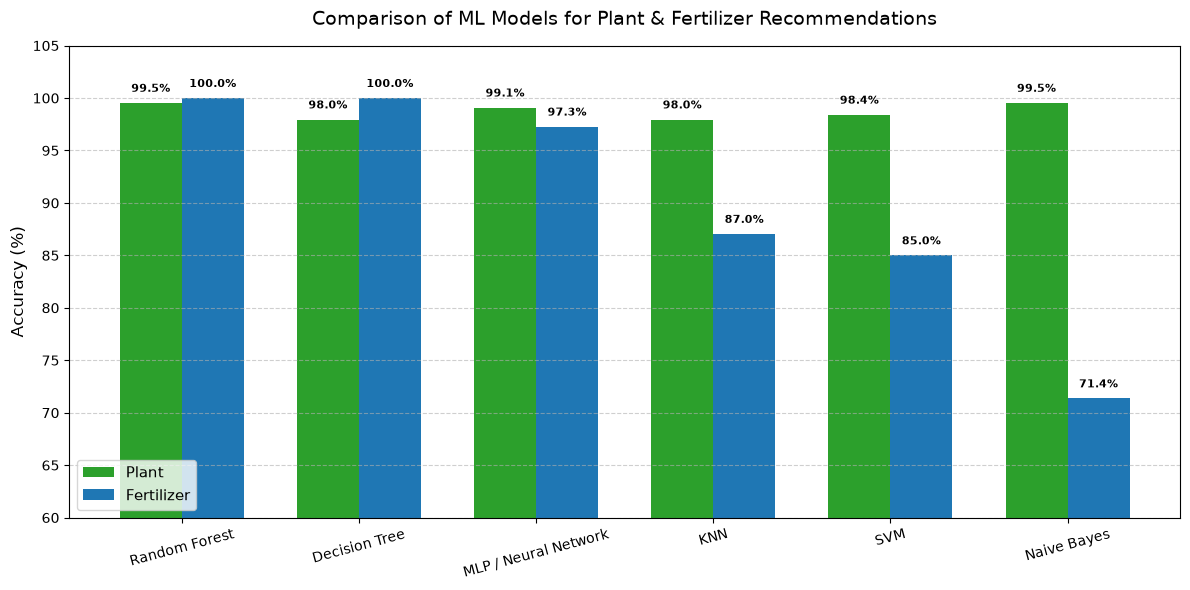

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

# 1. โหลดข้อมูล
df_p = pd.read_csv('Plant.csv')
df_f = pd.read_csv('Fertilizer.csv')

# Task 1: Plant Data
X_p = df_p[['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']]
y_p = df_p['label']
X_p_tr, X_p_te, y_p_tr, y_p_te = train_test_split(X_p, y_p, test_size=0.2, random_state=42, stratify=y_p)

# Task 2: Fertilizer Data
num_cols = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
cat_cols = ['label']
X_f = df_f[num_cols + cat_cols]
y_f = df_f['fertilizer']
X_f_tr, X_f_te, y_f_tr, y_f_te = train_test_split(X_f, y_f, test_size=0.2, random_state=42, stratify=y_f)

prep_tree = ColumnTransformer([('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)], remainder='passthrough')
prep_scaled = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
])

# นิยามโมเดลทั้ง 6
models = {
    'Decision Tree': (
        DecisionTreeClassifier(max_depth=12, random_state=42),
        Pipeline([('prep', prep_tree), ('clf', DecisionTreeClassifier(max_depth=12, random_state=42))])
    ),
    'Random Forest': (
        RandomForestClassifier(n_estimators=100, random_state=42),
        Pipeline([('prep', prep_tree), ('clf', RandomForestClassifier(n_estimators=100, random_state=42))])
    ),
    'KNN': (
        Pipeline([('scaler', StandardScaler()), ('clf', KNeighborsClassifier(n_neighbors=5))]),
        Pipeline([('prep', prep_scaled), ('clf', KNeighborsClassifier(n_neighbors=5))])
    ),
    'Naive Bayes': (
        GaussianNB(),
        Pipeline([('prep', prep_scaled), ('clf', GaussianNB())])
    ),
    'SVM': (
        Pipeline([('scaler', StandardScaler()), ('clf', SVC(kernel='rbf', C=1.0, random_state=42))]),
        Pipeline([('prep', prep_scaled), ('clf', SVC(kernel='rbf', C=1.0, random_state=42))])
    ),
    'MLP / Neural Network': (
        Pipeline([('scaler', StandardScaler()), ('clf', MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42))]),
        Pipeline([('prep', prep_scaled), ('clf', MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42))])
    )
}

# เทรนและเก็บค่าความแม่นยำ
summary = []
for name, (m_plant, m_fert) in models.items():
    m_plant.fit(X_p_tr, y_p_tr)
    acc_p = accuracy_score(y_p_te, m_plant.predict(X_p_te)) * 100

    m_fert.fit(X_f_tr, y_f_tr)
    acc_f = accuracy_score(y_f_te, m_fert.predict(X_f_te)) * 100

    summary.append({
        'Model': name,
        'Plant Accuracy (%)': acc_p,
        'Fertilizer Accuracy (%)': acc_f,
        'Average Accuracy (%)': (acc_p + acc_f) / 2
    })

comparison_df = pd.DataFrame(summary).sort_values(by='Average Accuracy (%)', ascending=False)
print("=== ตารางสรุปการทดสอบทุกโมเดล ===")
print(comparison_df.to_string(index=False))

# พล็อตกราฟเปรียบเทียบ
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(comparison_df))
width = 0.35

rects1 = ax.bar(x - width/2, comparison_df['Plant Accuracy (%)'], width, label='Plant', color='#2ca02c')
rects2 = ax.bar(x + width/2, comparison_df['Fertilizer Accuracy (%)'], width, label='Fertilizer', color='#1f77b4')

ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('Comparison of ML Models for Plant & Fertilizer Recommendations', fontsize=14, pad=15)
ax.set_xticks(x)
ax.set_xticklabels(comparison_df['Model'], rotation=15, fontsize=10)
ax.set_ylim(60, 105)
ax.legend(loc='lower left', fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.6)

for rect in list(rects1) + list(rects2):
    h = rect.get_height()
    ax.text(rect.get_x() + rect.get_width()/2., h + 0.8, f"{h:.1f}%", ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.show()

In [5]:
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier

# 1. โหลดข้อมูลและเทรนโมเดล
df_plant = pd.read_csv('Plant.csv')
features = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
X_p = df_plant[features]
y_p = df_plant['label']
model_plant = DecisionTreeClassifier(max_depth=12, random_state=42)
model_plant.fit(X_p, y_p)

df_fert = pd.read_csv('Fertilizer.csv')
X_f = df_fert[features + ['label']]
y_f = df_fert['fertilizer']
preprocessor = ColumnTransformer(
    [('cat', OneHotEncoder(handle_unknown='ignore'), ['label'])],
    remainder='passthrough',
)
model_fert = Pipeline([
    ('prep', preprocessor),
    ('tree', DecisionTreeClassifier(max_depth=12, random_state=42)),
])
model_fert.fit(X_f, y_f)

# 2. ป้อนค่าทดสอบตรงนี้ (แก้ไขตัวเลขตามต้องการได้เลย)
input_data = {
    'N': 4,  # ไนโตรเจน (0 - 140)
    'P': 7,  # ฟอสฟอรัส (5 - 145)
    'K': 10,  # โพแทสเซียม (5 - 205)
    'temperature': 20.8,  # อุณหภูมิ °C (8.5 - 45.0)
    'humidity': 82.0,  # ความชื้น % (14.0 - 100.0)
    'ph': 6.5,  # pH ดิน (3.5 - 10.0)
    'rainfall': 202.0,  # น้ำฝน mm (20.0 - 300.0)
}

# 3. ทำนายผล
input_df = pd.DataFrame([input_data])
predicted_crop = model_plant.predict(input_df)[0]

input_df['label'] = predicted_crop
predicted_fert = model_fert.predict(input_df)[0]

print('=' * 55)
print('🎯 ผลการทำนายจากสภาพดินและอากาศที่กำหนด:')
print('=' * 55)
print(f'🌱 พืชที่แนะนำให้ปลูก : {predicted_crop.upper()}')
print(f'🧪 สูตรปุ๋ยที่แนะนำใช้  : {predicted_fert}')
print('=' * 55)

🎯 ผลการทำนายจากสภาพดินและอากาศที่กำหนด:
🌱 พืชที่แนะนำให้ปลูก : COCONUT
🧪 สูตรปุ๋ยที่แนะนำใช้  : Balanced NPK (10-26-26)
